# Mermin's Inequality on IQM Hardware — Generalized Implementation

Implements the protocol of

> P. De Fabritiis, I. Roditi, S.P. Sorella,
> *"Mermin's inequalities in Quantum Field Theory"*,
> Phys. Lett. B **846** (2023) 138198.

for arbitrary `n` on real **IQM Crystal-class** quantum hardware
(Garnet 20-qubit, Emerald 54-qubit) accessed via IQM Resonance.

**No hardcoded topology.** The coupling graph and qubit names always
come from the live backend (`backend.coupling_map`,
`backend.index_to_qubit_name`) or from a calibration JSON downloaded
from Resonance (CZ pairs in the JSON define the edges).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

from polynomial import (
    mermin_polynomial,
    format_polynomial,
    ghz_expectation_value,
    standard_optimal_angles,
    quantum_bound,
    classical_bound,
)
from topology import (
    # Topology constructors (data-driven)
    topology_from_iqm_backend,
    topology_from_calibration,
    topology_from_calibration_json,
    # Calibration helpers
    parse_calibration_json,
    # Chain selection
    find_best_chain_path,
)
from runner import run_mermin_test

print('mermin_iqm imported cleanly')

mermin_iqm imported cleanly


In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Load .env from the directory containing this notebook
load_dotenv(Path.cwd() / ".env", override=True)
assert os.environ.get("IQM_TOKEN"), "IQM_TOKEN not set — check .env path"

---
## 1. The Mermin polynomial

The paper's recursion (Eq. 1):

$$M_n = \tfrac12 M_{n-1}(A_n + A_n') + \tfrac12 M_{n-1}'(A_n - A_n'), \qquad M_1 = 2A_1,$$

where $M_k'$ swaps every primed/unprimed operator. We expand it into a
sum of Pauli products.

In [3]:
for n in range(2, 7):
    poly = mermin_polynomial(n)
    print(f'M_{n}  ({len(poly):>4d} nonzero terms):  {format_polynomial(poly)}')

M_2  (   4 nonzero terms):  +AB +AB' +A'B -A'B'
M_3  (   4 nonzero terms):  +ABC' +AB'C +A'BC -A'B'C'
M_4  (  16 nonzero terms):  -0.5*ABCD +0.5*ABCD' +0.5*ABC'D +0.5*ABC'D' +0.5*AB'CD +0.5*AB'CD' +0.5*AB'C'D -0.5*AB'C'D' +0.5*A'BCD +0.5*A'BCD' +0.5*A'BC'D -0.5*A'BC'D' +0.5*A'B'CD -0.5*A'B'CD' -0.5*A'B'C'D -0.5*A'B'C'D'
M_5  (  16 nonzero terms):  -0.5*ABCDE +0.5*ABCD'E' +0.5*ABC'DE' +0.5*ABC'D'E +0.5*AB'CDE' +0.5*AB'CD'E +0.5*AB'C'DE -0.5*AB'C'D'E' +0.5*A'BCDE' +0.5*A'BCD'E +0.5*A'BC'DE -0.5*A'BC'D'E' +0.5*A'B'CDE -0.5*A'B'CD'E' -0.5*A'B'C'DE' -0.5*A'B'C'D'E
M_6  (  64 nonzero terms):  -0.25*ABCDEF -0.25*ABCDEF' -0.25*ABCDE'F +0.25*ABCDE'F' -0.25*ABCD'EF +0.25*ABCD'EF' +0.25*ABCD'E'F +0.25*ABCD'E'F' -0.25*ABC'DEF +0.25*ABC'DEF' +0.25*ABC'DE'F +0.25*ABC'DE'F' +0.25*ABC'D'EF +0.25*ABC'D'EF' +0.25*ABC'D'E'F -0.25*ABC'D'E'F' -0.25*AB'CDEF +0.25*AB'CDEF' +0.25*AB'CDE'F +0.25*AB'CDE'F' +0.25*AB'CD'EF +0.25*AB'CD'EF' +0.25*AB'CD'E'F -0.25*AB'CD'E'F' +0.25*AB'C'DEF +0.25*AB'C'DEF' +0.25*AB'C'

Verify the standard angles saturate the QM bound:

In [4]:
for n in range(2, 11):
    qb = quantum_bound(n)
    cb = classical_bound(n)
    a, b = standard_optimal_angles(n)
    poly = mermin_polynomial(n)
    val = ghz_expectation_value(poly, a, b)
    print(f'n={n:>2d}  classical {cb:5.3f}  quantum {qb:9.4f}  '
          f'GHZ value {val:+9.4f}  saturates? {abs(abs(val)-qb) < 1e-9}')

n= 2  classical 2.000  quantum    2.8284  GHZ value   +2.8284  saturates? True
n= 3  classical 2.000  quantum    4.0000  GHZ value   +4.0000  saturates? True
n= 4  classical 2.000  quantum    5.6569  GHZ value   +5.6569  saturates? True
n= 5  classical 2.000  quantum    8.0000  GHZ value   +8.0000  saturates? True
n= 6  classical 2.000  quantum   11.3137  GHZ value  +11.3137  saturates? True
n= 7  classical 2.000  quantum   16.0000  GHZ value  +16.0000  saturates? True
n= 8  classical 2.000  quantum   22.6274  GHZ value  +22.6274  saturates? True
n= 9  classical 2.000  quantum   32.0000  GHZ value  +32.0000  saturates? True
n=10  classical 2.000  quantum   45.2548  GHZ value  +45.2548  saturates? True


---
## 2. Topology: pulled live from an IQM backend (no hardcoding)

On a real machine, `topology_from_iqm_backend(backend)` reads
`backend.coupling_map` and `backend.index_to_qubit_name`. For local
experiments and CI we use **`IQMFakeApollo`** (Crystal-20, the Garnet
shape) and **`IQMFakeAphrodite`** (Crystal-54, the Emerald shape).

If `iqm-client[qiskit]` isn't installed, skip ahead to the
calibration-JSON path.

In [5]:
try:
    from iqm.qiskit_iqm import IQMFakeApollo, IQMFakeAphrodite
    fake_garnet = IQMFakeApollo()
    fake_emerald = IQMFakeAphrodite()
    g = topology_from_iqm_backend(fake_garnet)
    e = topology_from_iqm_backend(fake_emerald)
    print('Garnet  (from IQMFakeApollo):  ', g)
    print('Emerald (from IQMFakeAphrodite):', e)
    print()
    print('First 5 edges of Garnet, with qubit names:')
    for a, b in g.edges:
        print(f'  ({a}, {b})  <->  ({g.name_of(a)}, {g.name_of(b)})')
except ImportError:
    print('iqm-client[qiskit] not installed in this kernel.')
    print('Skip to the calibration-JSON path below.')

Garnet  (from IQMFakeApollo):   Topology('IQMFakeApolloBackend', 20 qubits, 30 edges, no calibration)
Emerald (from IQMFakeAphrodite): Topology('IQMFakeAphroditeBackend', 54 qubits, 90 edges, no calibration)

First 5 edges of Garnet, with qubit names:
  (0, 1)  <->  (QB1, QB2)
  (0, 3)  <->  (QB1, QB4)
  (1, 4)  <->  (QB2, QB5)
  (2, 3)  <->  (QB3, QB4)
  (2, 7)  <->  (QB3, QB8)
  (3, 8)  <->  (QB4, QB9)
  (3, 4)  <->  (QB4, QB5)
  (4, 9)  <->  (QB5, QB10)
  (4, 5)  <->  (QB5, QB6)
  (5, 10)  <->  (QB6, QB11)
  (5, 6)  <->  (QB6, QB7)
  (6, 11)  <->  (QB7, QB12)
  (7, 8)  <->  (QB8, QB9)
  (7, 12)  <->  (QB8, QB13)
  (8, 9)  <->  (QB9, QB10)
  (8, 13)  <->  (QB9, QB14)
  (9, 10)  <->  (QB10, QB11)
  (9, 14)  <->  (QB10, QB15)
  (10, 11)  <->  (QB11, QB12)
  (10, 15)  <->  (QB11, QB16)
  (11, 16)  <->  (QB12, QB17)
  (12, 13)  <->  (QB13, QB14)
  (13, 17)  <->  (QB14, QB18)
  (13, 14)  <->  (QB14, QB15)
  (14, 18)  <->  (QB15, QB19)
  (14, 15)  <->  (QB15, QB16)
  (15, 16)  <->  (QB16, 

### 2b. Topology from a downloaded calibration JSON

On Resonance you can click *Download calibration data* on any device
page and save a JSON. The CZ-fidelity entries in that file *are* the
coupling graph: an edge exists iff a CZ fidelity is reported for it.

Below we synthesize a Resonance-style observation list (the actual
shape that file uses) so the demo runs without a real download:

In [6]:
import json, random
random.seed(0)

# 5x4 grid (the Crystal-20 shape) — synthetic observations
obs = []
for i in range(1, 21):
    obs.append({'dut_field': f'QB{i}.prx.fidelity', 'value': 0.999})
    obs.append({'dut_field': f'QB{i}.t1.t1',        'value': 50e-6 + random.random()*1e-6})
    obs.append({'dut_field': f'QB{i}.t2.echo',      'value': 25e-6 + random.random()*1e-6})
    obs.append({'dut_field': f'QB{i}.readout.fidelity', 'value': 0.95 + random.random()*0.04})
for r in range(5):
    for c in range(3):
        a, b = 4*r+c+1, 4*r+c+2
        obs.append({'dut_field': f'QB{a}.QB{b}.cz.fidelity',
                    'value': 0.99 - random.random()*0.05})
for r in range(4):
    for c in range(4):
        a, b = 4*r+c+1, 4*(r+1)+c+1
        obs.append({'dut_field': f'QB{a}.QB{b}.cz.fidelity',
                    'value': 0.99 - random.random()*0.05})

with open('synthetic_calibration.json', 'w') as f:
    json.dump(obs, f)

cal = parse_calibration_json('synthetic_calibration.json')
print(f'parsed {len(cal["CZ"])//2} unique CZ pairs (both orderings stored)')
print(f'parsed {len(cal["1Q"])} 1Q fidelities')
print(f'parsed {len(cal["t1"])} T1, {len(cal["t2"])} T2')
print()
top = topology_from_calibration_json('synthetic_calibration.json',
                                     name='SyntheticGarnet')
print(top)
print(f'first 5 edges  : {top.edges[:5]}')

parsed 31 unique CZ pairs (both orderings stored)
parsed 20 1Q fidelities
parsed 20 T1, 20 T2

Topology('SyntheticGarnet', 20 qubits, 31 edges, calibrated: 31 CZ, 20 1Q, 20 T1)
first 5 edges  : [(0, 1), (0, 4), (1, 2), (1, 5), (2, 3)]


---
## 3. Three ways to pick a chain — all data-driven

1. **`chain_strategy='iqm_or_auto'` (default)** — try the official
   IQM Qubit Selector (`CostEvaluator`), fall back to a local DFS.
2. **`chain_strategy='user'` / `'user_or_auto'`** — supply the chain as
   either qiskit qubit indices or canonical IQM names (`'QB7'`).
3. **`chain_strategy='auto'`** — local DFS only.

In [7]:
for n in (3, 5, 8, 12):
    sel = find_best_chain_path(top, n)
    names = sel.chain_names(top)
    print(f'n={n:>2d}  chain {sel.chain}  ({names})  score {sel.score:.4f}')

n= 3  chain [5, 4, 0]  (['QB6', 'QB5', 'QB1'])  score 0.8793
n= 5  chain [9, 10, 14, 13, 12]  (['QB10', 'QB11', 'QB15', 'QB14', 'QB13'])  score 0.7862
n= 8  chain [0, 4, 5, 9, 10, 14, 13, 12]  (['QB1', 'QB5', 'QB6', 'QB10', 'QB11', 'QB15', 'QB14', 'QB13'])  score 0.6533
n=12  chain [0, 4, 5, 6, 7, 11, 15, 14, 13, 12, 8, 9]  (['QB1', 'QB5', 'QB6', 'QB7', 'QB8', 'QB12', 'QB16', 'QB15', 'QB14', 'QB13', 'QB9', 'QB10'])  score 0.4943


---
## 4. Run on the simulator (sanity check)

In [8]:
result = run_mermin_test(n=3, shots=8192, verbose=True)

[backend] AerSimulator  (simulator=True)
[topology] Topology('simulator-line', 3 qubits, 2 edges, no calibration)
Mermin problem n=3
  number of nonzero terms in M_n  : 4
  classical bound  |M_n|_Cl       : 2.0
  quantum   bound  |M_n|_QM       : 4.000000
  theoretical value with chosen   : 4.000000
  ratio achieved / quantum bound  : 1.0000
[chain] indices [0, 1, 2]  names ['QB1', 'QB2', 'QB3']
        score=0.9510  reason=auto: highest-fidelity connected path
[circuits] 4 term-circuits built
[job] submitted; waiting for results...
----------------------------------------------------------------
Mermin experiment  n=3
  backend                : AerSimulator
  qubit chain            : [0, 1, 2]
  chain selection reason : auto: highest-fidelity connected path  |  qubits: ['QB1', 'QB2', 'QB3']
  shots per term         : 8192
  number of terms in M_n : 4
  classical bound        : 2.0
  quantum   bound        : 4.000000
  ideal <M_n>_GHZ        : +4.000000
  measured <M_n>         : +4.00

Sweep n = 2 ... 8 and compare to the bounds:

In [10]:
ns = list(range(2, 9))
rows = []
for n in ns:
    res = run_mermin_test(n=n, shots=4096, verbose=False)
    rows.append((n, abs(res.value), res.value_sem,
                 res.problem.theoretical_value,
                 res.problem.classical_bound,
                 res.problem.quantum_bound))
    print(f'n={n}  <M_n>={res.value:+8.4f}  theory={res.problem.theoretical_value:+8.4f}'
          f'  qb={res.problem.quantum_bound:8.4f}')

n=2  <M_n>= +2.8379  theory= +2.8284  qb=  2.8284
n=3  <M_n>= +4.0000  theory= +4.0000  qb=  4.0000
n=4  <M_n>= +5.6658  theory= +5.6569  qb=  5.6569
n=5  <M_n>= +8.0000  theory= +8.0000  qb=  8.0000
n=6  <M_n>=+11.3082  theory=+11.3137  qb= 11.3137
n=7  <M_n>=+16.0000  theory=+16.0000  qb= 16.0000
n=8  <M_n>=+22.6149  theory=+22.6274  qb= 22.6274


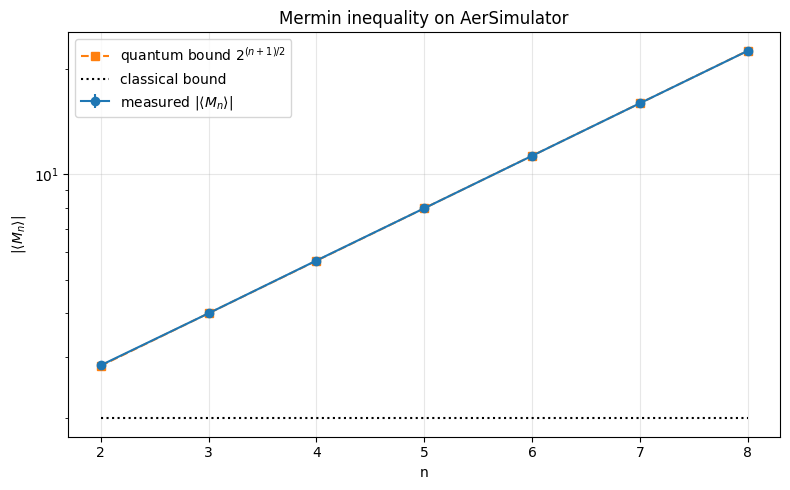

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ns_arr = np.array([r[0] for r in rows])
vals = np.array([r[1] for r in rows])
sems = np.array([r[2] for r in rows])
qb = np.array([r[5] for r in rows])
cb = np.array([r[4] for r in rows])

ax.errorbar(ns_arr, vals, yerr=sems, fmt='o-', label=r'measured $|\langle M_n \rangle|$')
ax.plot(ns_arr, qb, 's--', label=r'quantum bound $2^{(n+1)/2}$')
ax.plot(ns_arr, cb, 'k:', label='classical bound')
ax.set_xlabel('n')
ax.set_ylabel(r'$|\langle M_n \rangle|$')
ax.set_title('Mermin inequality on AerSimulator')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Failure-handling: hardware edge cases

**(a) User-supplied chain that isn't a connected path.** The runner
logs a warning and falls back.

In [12]:
res = run_mermin_test(
    n=4, shots=1024,
    qubit_chain=['QB1', 'QB13', 'QB5', 'QB9'],   # not connected on Crystal-20
    chain_strategy='user_or_auto',
    topology=top,
    fetch_live_calibration=False,
    verbose=False,
)
print('  fallback chain:', res.physical_qubits, '\n  reason:', res.chain_reason)

  [chain] user-supplied chain ['QB1', 'QB13', 'QB5', 'QB9'] is not a valid path of length 4 in 'SyntheticGarnet'; falling back to auto
  fallback chain: [12, 13, 14, 15] 
  reason: auto: highest-fidelity connected path  |  qubits: ['QB13', 'QB14', 'QB15', 'QB16']


**(b) Auto chain selection on Crystal-54 emulated topology.**

In [13]:
res = run_mermin_test(
    n=8, shots=1024,
    chain_strategy='auto',
    topology=top,
    fetch_live_calibration=False,
    verbose=False,
)
print('  auto chain:', res.physical_qubits)
print('  qubit names:', [top.name_of(q) for q in res.physical_qubits])
print('  <M_8>:', f'{res.value:+.4f}', '  theory:', f'{res.problem.theoretical_value:+.4f}')

  auto chain: [0, 4, 5, 9, 10, 14, 13, 12]
  qubit names: ['QB1', 'QB5', 'QB6', 'QB10', 'QB11', 'QB15', 'QB14', 'QB13']
  <M_8>: +22.6660   theory: +22.6274


**(c) Requesting a chain bigger than the device.** Hard error.

In [14]:
try:
    run_mermin_test(n=25, shots=128, topology=top, verbose=False)
except ValueError as ex:
    print('rejected:', ex)

rejected: n=25 impractical: M_n has up to 2^25 circuits; pick n<=20


**(d) `strategy='user'` (no fallback) with an invalid chain.** Hard error.

In [15]:
try:
    run_mermin_test(
        n=3, shots=128,
        qubit_chain=['QB1', 'QB13', 'QB5'],
        chain_strategy='user',
        topology=top,
        fetch_live_calibration=False,
        verbose=False,
    )
except ValueError as ex:
    print('rejected:', ex)

rejected: user chain ['QB1', 'QB13', 'QB5'] not valid in 'SyntheticGarnet'


**(e) Bad calibration on a region of the chip.** The selector avoids it.

In [16]:
import copy
tanked = copy.deepcopy(cal)
for key in list(tanked['CZ']):
    nums = [int(s.replace('QB','').strip()) for s in key.replace('[','').replace(']','').split(',')]
    if any(q in (5, 6, 7, 8) for q in nums):
        tanked['CZ'][key] = 0.80

tanked_top = topology_from_calibration(tanked, name='TankedGarnet')
sel_baseline = find_best_chain_path(top, 4)
sel_tanked = find_best_chain_path(tanked_top, 4)
print(f'baseline best chain: {sel_baseline.chain_names(top)}        score {sel_baseline.score:.4f}')
print(f'  tanked best chain: {sel_tanked.chain_names(tanked_top)}   score {sel_tanked.score:.4f}')
print('  -> selector successfully avoided the bad region')

baseline best chain: ['QB13', 'QB14', 'QB15', 'QB16']        score 0.8342
  tanked best chain: ['QB13', 'QB14', 'QB15', 'QB16']   score 0.8342
  -> selector successfully avoided the bad region


---
## 6. Connecting to a real IQM backend (template)

Get a token at https://resonance.meetiqm.com and pass it via the
`IQM_TOKEN` environment variable.

In [34]:
TEMPLATE = '''
import os
result = run_mermin_test(
    n=4,
    iqm_server_url="https://cocos.resonance.meetiqm.com/garnet",
    iqm_device="garnet",
    chain_strategy="iqm_or_auto",
    shots=8192,
)
print(result.summary())
'''
print(TEMPLATE)


import os
result = run_mermin_test(
    n=4,
    iqm_server_url="https://cocos.resonance.meetiqm.com/garnet",
    iqm_device="garnet",
    chain_strategy="iqm_or_auto",
    shots=8192,
)
print(result.summary())



---
## 6b. Hardware sweep: n = 4 … 10

Runs Mermin tests for each n under two chain-selection strategies—
**iqm_or_auto** (IQM Qubit Selector) and a **user-defined chain**—
saves every run to a CSV, then plots the measured |⟨Mn⟩| against the
classical and quantum bounds.

In [3]:
# ── IQM sweep configuration (edit here) ─────────────────────────────────────
N_VALUES   = list(range(4, 10))        # n = 4, 5, …, 9
SHOTS      = 1024
CSV_PATH   = "iqm_results.csv"

# User-defined qubit chain; for each n the first n entries are used.
USER_CHAIN = ["QB7", "QB6", "QB11", "QB10", "QB15", "QB14", "QB18",
              "QB19", "QB20", "QB16"]

In [4]:
import csv, datetime

def _run_sweep(strategy_label, chain_strategy, qubit_chain=None):
    """Run the Mermin sweep and return a list of result dicts."""
    rows = []
    for n in N_VALUES:
        chain_n = qubit_chain[:n] if qubit_chain else None
        result = run_mermin_test(
            n=n,
            iqm_server_url=os.environ["IQM_SERVER_URL"],
            iqm_device=os.environ["IQM_DEVICE"],
            chain_strategy=chain_strategy,
            qubit_chain=chain_n,
            shots=SHOTS,
        )
        print(result.summary())
        rows.append({
            "timestamp":          datetime.datetime.utcnow().isoformat(),
            "strategy":           strategy_label,
            "n":                  n,
            "shots":              SHOTS,
            "measured_value":     result.value,
            "sem":                result.value_sem,
            "theoretical_value":  result.problem.theoretical_value,
            "classical_bound":    result.problem.classical_bound,
            "quantum_bound":      result.problem.quantum_bound,
            "ratio_quantum":      abs(result.value) / result.problem.quantum_bound,
            "ratio_classical":    abs(result.value) / result.problem.classical_bound,
            "violates_classical": abs(result.value) > result.problem.classical_bound,
            "physical_qubits":    str(result.physical_qubits),
            "chain_reason":       result.chain_reason,
        })
    return rows

all_rows  = _run_sweep("iqm_or_auto", "iqm_or_auto")
all_rows += _run_sweep("user_chain",  "user_or_auto", USER_CHAIN)

with open(CSV_PATH, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(all_rows[0].keys()))
    writer.writeheader()
    writer.writerows(all_rows)

print(f"Results saved → {CSV_PATH}  ({len(all_rows)} rows)")

[backend] IQMBackend  (simulator=False)
[topology] Topology('IQMBackend', 20 qubits, 30 edges, no calibration)
Mermin problem n=4
  number of nonzero terms in M_n  : 16
  classical bound  |M_n|_Cl       : 2.0
  quantum   bound  |M_n|_QM       : 5.656854
  theoretical value with chosen   : 5.656854
  ratio achieved / quantum bound  : 1.0000
[chain] indices [0, 3, 8, 13]  names ['QB1', 'QB4', 'QB9', 'QB14']
        score=0.9321  reason=auto: highest-fidelity connected path
[circuits] 16 term-circuits built
[job] submitted; waiting for results...
----------------------------------------------------------------
Mermin experiment  n=4
  backend                : IQMBackend
  qubit chain            : [0, 3, 8, 13]
  chain selection reason : auto: highest-fidelity connected path  |  qubits: ['QB1', 'QB4', 'QB9', 'QB14']
  shots per term         : 1024
  number of terms in M_n : 16
  classical bound        : 2.0
  quantum   bound        : 5.656854
  ideal <M_n>_GHZ        : +5.656854
  measured

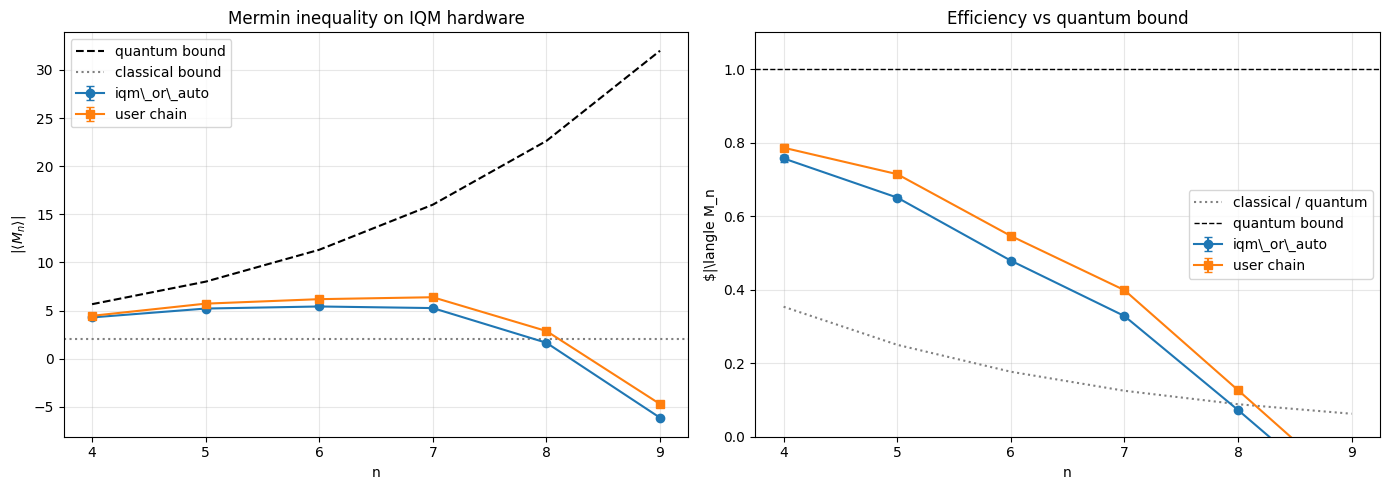

Plot saved → iqm_results.png


In [8]:
import pandas as pd

df  = pd.read_csv(CSV_PATH)
ns  = np.sort(df["n"].unique())
qb  = np.array([df[df["n"] == n]["quantum_bound"].iloc[0] for n in ns])
cb  = float(df["classical_bound"].iloc[0])

style = {
    "iqm_or_auto": dict(color="C0", marker="o", label="iqm\_or\_auto"),
    "user_chain":  dict(color="C1", marker="s", label="user chain"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: |M_n| vs n ───────────────────────────────────────────────────────────
ax = axes[0]
for strat, st in style.items():
    sub = df[df["strategy"] == strat].sort_values("n")
    qb_sub = np.array([df[df["n"] == n]["quantum_bound"].iloc[0] for n in sub["n"]])
    ax.errorbar(sub["n"], sub["measured_value"], yerr=sub["sem"],
                fmt=f'{st["marker"]}-', color=st["color"],
                label=st["label"], capsize=3)
ax.plot(ns, qb, "k--", label="quantum bound")
ax.axhline(cb, color="gray", linestyle=":", linewidth=1.5, label="classical bound")
ax.set_xlabel("n")
ax.set_ylabel(r"$|\langle M_n \rangle|$")
ax.set_title("Mermin inequality on IQM hardware")
# ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.3)

# Right: |M_n| / quantum bound vs n ─────────────────────────────────────────
ax = axes[1]
for strat, st in style.items():
    sub = df[df["strategy"] == strat].sort_values("n")
    qb_sub = np.array([df[df["n"] == n]["quantum_bound"].iloc[0] for n in sub["n"]])
    ax.errorbar(sub["n"], sub["measured_value"] / qb_sub,
                yerr=sub["sem"] / qb_sub,
                fmt=f'{st["marker"]}-', color=st["color"],
                label=st["label"], capsize=3)
ax.plot(ns, cb / qb, "gray", linestyle=":", linewidth=1.5,
        label="classical / quantum")
ax.axhline(1.0, color="k", linestyle="--", linewidth=1, label="quantum bound")
ax.set_xlabel("n")
ax.set_ylabel(r"$|\langle M_n")
ax.set_title("Efficiency vs quantum bound")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("iqm_results.png", dpi=150)
plt.show()
print("Plot saved → iqm_results.png")

---
## 7. Per-term breakdown

In [9]:
res = run_mermin_test(n=4, shots=4096, verbose=False)
print(f'<M_4> = {res.value:+.4f}\n')
print(f'{"pattern":>12} {"coef":>8} {"<term>":>10} {"sem":>8}')
for t in res.term_results:
    pat_str = ''.join("'" if p else 'X' for p in t.pattern)
    print(f'{pat_str:>12} {t.coefficient:>+8.3f} {t.expectation:>+10.4f} {t.sem:>8.4f}')

<M_4> = +5.6416

     pattern     coef     <term>      sem
        XXXX   -0.500    -0.7026   0.0111
        XXX'   +0.500    +0.6987   0.0112
        XX'X   +0.500    +0.6943   0.0112
        XX''   +0.500    +0.7144   0.0109
        X'XX   +0.500    +0.6948   0.0112
        X'X'   +0.500    +0.7183   0.0109
        X''X   +0.500    +0.6997   0.0112
        X'''   -0.500    -0.7021   0.0111
        'XXX   +0.500    +0.6934   0.0113
        'XX'   +0.500    +0.6953   0.0112
        'X'X   +0.500    +0.6973   0.0112
        'X''   -0.500    -0.7056   0.0111
        ''XX   +0.500    +0.7256   0.0108
        ''X'   -0.500    -0.7119   0.0110
        '''X   -0.500    -0.7192   0.0109
        ''''   -0.500    -0.7100   0.0110


---
## 8. Final report

In [10]:
res = run_mermin_test(n=5, shots=8192, verbose=False)
print(res.summary())

----------------------------------------------------------------
Mermin experiment  n=5
  backend                : AerSimulator
  qubit chain            : [0, 1, 2, 3, 4]
  chain selection reason : auto: highest-fidelity connected path  |  qubits: ['QB1', 'QB2', 'QB3', 'QB4', 'QB5']
  shots per term         : 8192
  number of terms in M_n : 16
  classical bound        : 2.0
  quantum   bound        : 8.000000
  ideal <M_n>_GHZ        : +8.000000
  measured <M_n>         : +8.000000  (+/- 0.0000)
  |M_n| / quantum bound  : 1.0000
  violates classical?    : YES (8.0000 vs 2.0)
----------------------------------------------------------------
